# Анализ на големи данни за недвижими имоти


# Въведение
Целта на проекта е да се изгради модел за прогнозиране на цена на недвижим имот по таблични данни.

Използван е dataset Housing.csv, съдържащ 545 записа и 13 колони. Данните описват характеристики на жилищни имоти като площ, брой спални, брой бани, етажност, наличие на климатик, обзавеждане и други признаци.

В проекта се използва подход с FastAI и tabular_learner, който е подходящ за tabular data regression задача, при която целевата променлива е цената на имота.

# Зареждане на библиотеки

В тази секция се зареждат необходимите библиотеки за обработка на данните, обучение на модела и оценка на резултатите.

In [40]:
!pip -q install fastai pandas scikit-learn

In [41]:
import pandas as pd
import numpy as np
from fastai.tabular.all import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Зареждане на dataset
Dataset-ът се качва ръчно в Google Colab и се зарежда чрез `pandas`. Използваният файл е `Housing.csv`.

In [8]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing (1).csv


In [42]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Преглед на данните
В тази секция се разглеждат размерът на dataset-а, имената на колоните и липсващите стойности. Това е важна стъпка преди подготовката на данните и обучението на модела.

In [10]:
print(df.shape)
print(df.columns.tolist())

(545, 13)
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [11]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [24]:
df.describe(include='all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


# Подготовка на данните
В тази секция се определят:
- целевата променлива (`price`)
- категориалните признаци
- числовите признаци
- трансформациите за предварителна обработка

Използват се:
- `Categorify` – за обработка на категориалните колони
- `FillMissing` – за попълване на липсващи стойности
- `Normalize` – за нормализация на числовите стойности

In [25]:
df['price_log'] = np.log1p(df['price'])

dep_var = 'price_log'

cat_names = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

cont_names = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

procs = [Categorify, FillMissing, Normalize]

# Създаване на DataLoaders
В тази секция данните се разделят на обучаваща и валидационна част. За целта се използва `TabularDataLoaders.from_df`, който създава подходящ вход за `FastAI` модела.

In [28]:
dls = TabularDataLoaders.from_df(
    df,
    path='.',
    y_names=dep_var,
    cat_names=cat_names,
    cont_names=cont_names,
    procs=procs,
    y_block=RegressionBlock(),
    valid_pct=0.2,
    seed=42
)

In [27]:
dls.show_batch()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus,area,bedrooms,bathrooms,stories,parking,price_log
0,yes,yes,yes,no,no,yes,unfurnished,4050.000057,2.0,1.0,2.0,-1.187485e-08,15.199302
1,yes,yes,yes,no,yes,yes,furnished,5700.000008,3.0,1.0,1.0,2.000000e+00,15.710128
2,yes,no,no,no,no,no,furnished,3000.000004,2.0,1.0,2.0,-1.187485e-08,14.739770
3,yes,no,no,no,no,no,unfurnished,3850.000047,3.0,1.0,1.0,-1.187485e-08,15.048071
4,yes,no,no,no,yes,yes,unfurnished,10239.999868,2.0,1.0,1.0,2.000000e+00,15.375758
5,yes,yes,no,no,no,no,semi-furnished,6000.000023,3.0,2.0,2.0,1.000000e+00,15.781223
6,yes,no,no,no,yes,no,furnished,3640.000063,3.0,1.0,2.0,-1.187485e-08,15.330638
7,yes,no,yes,no,no,yes,semi-furnished,11439.999928,4.0,1.0,2.0,1.000000e+00,15.809258
8,no,no,no,no,no,no,semi-furnished,3090.000035,3.0,1.0,2.0,-1.187485e-08,14.917451
9,yes,no,no,no,no,no,unfurnished,3619.999983,2.0,1.0,1.0,-1.187485e-08,14.375127


# Обучение на модела
За обучението се използва `tabular_learner` от FastAI. Моделът е подходящ за regression задача, при която крайната цел е прогнозиране на числова стойност – в случая цената на имота.

In [29]:
learn = tabular_learner(dls, layers=[200, 100], metrics=[mae, rmse])

In [30]:
learn.fit_one_cycle(10, 1e-2)

epoch,train_loss,valid_loss,mae,_rmse,time
0,235.906128,238.019638,15.424601,15.427886,00:00
1,234.385605,237.673523,15.413875,15.416664,00:00
2,228.105331,218.049484,14.761435,14.766499,00:00
3,213.294220,160.345779,12.651013,12.662771,00:00
4,189.565811,92.095558,9.567280,9.596643,00:00
5,161.769501,39.126167,6.199127,6.255091,00:00
6,135.271759,16.112244,3.987314,4.014006,00:00
7,112.828857,9.111861,2.955080,3.018586,00:00
8,94.741135,6.546155,2.494163,2.558546,00:00
9,80.372696,6.406981,2.469756,2.531202,00:00


In [31]:
learn.fit_one_cycle(5, 1e-2)

epoch,train_loss,valid_loss,mae,_rmse,time
0,4.866787,1.899989,1.266254,1.378401,00:00
1,2.755751,1.684087,0.957090,1.297724,00:00
2,2.522343,2.780620,1.544808,1.667519,00:00
3,2.248801,1.348112,1.048344,1.161082,00:00
4,1.942429,0.933911,0.840710,0.966391,00:00


# Оценка на резултатите
След обучението на модела се изчисляват стандартни regression метрики:
- **MAE** – средна абсолютна грешка
- **RMSE** – корен от средноквадратичната грешка
- **R²** – коефициент на детерминация

Тези метрики показват колко добре моделът прогнозира цената на имотите.

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preds, targs = learn.get_preds()

preds = preds.squeeze().numpy()
targs = targs.squeeze().numpy()

# Връщане от log(price) към реална цена
preds_real = np.expm1(preds)
targs_real = np.expm1(targs)

mae_value = mean_absolute_error(targs_real, preds_real)
rmse_value = mean_squared_error(targs_real, preds_real) ** 0.5
r2_value = r2_score(targs_real, preds_real)

print("MAE =", mae_value)
print("RMSE =", rmse_value)
print("R2 =", r2_value)

MAE = 9318921.0
RMSE = 24672213.754757557
R2 = -199.73809814453125


Получените метрики показват, че моделът е демонстрационен и има ограничения по отношение на точността. Въпреки това проектът успешно илюстрира процеса по подготовка на таблични данни, обучение на модел и извличане на прогнози.

# Визуализация и примерна прогноза
В тази секция се визуализира връзката между реалните и прогнозирани стойности. Освен това се прави примерна прогноза за конкретен имот от dataset-а.

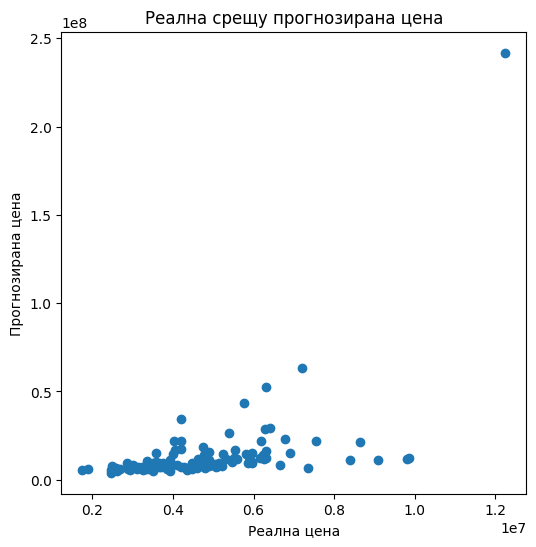

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(targs_real, preds_real)
plt.xlabel("Реална цена")
plt.ylabel("Прогнозирана цена")
plt.title("Реална срещу прогнозирана цена")
plt.show()

In [39]:
sample_full = df.sample(1, random_state=42)
real_price = sample_full['price'].values[0]

sample = sample_full.drop(columns=['price', 'price_log'])
dl = learn.dls.test_dl(sample)
sample_pred_log, _ = learn.get_preds(dl=dl)
predicted_price = np.expm1(float(sample_pred_log[0]))

print(f"Реална цена: {real_price:,.2f}")
print(f"Прогнозна цена: {predicted_price:,.2f}")
print(f"Абсолютна грешка: {abs(real_price - predicted_price):,.2f}")

Реална цена: 4,060,000.00
Прогнозна цена: 12,112,650.55
Абсолютна грешка: 8,052,650.55


# Заключение

В проекта беше използван dataset Housing.csv, съдържащ таблични данни за недвижими имоти.

Целта беше да се прогнозира цената на имот въз основа на характеристики като площ, брой спални, брой бани, етажност, паркоместа, наличие на климатик, обзавеждане и други признаци.

Беше изграден модел чрез FastAI `tabular_learner`, като данните бяха предварително обработени чрез категориализация, попълване на липсващи стойности и нормализация.

Получените резултати показват, че табличните данни могат да бъдат използвани за изграждане на модел за прогнозиране на цени на недвижими имоти. Проектът демонстрира основните етапи на обработка на данни, обучение на модел и оценка на резултатите.